In [14]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sb
import globals as gl
from matplotlib.colors import LinearSegmentedColormap, Normalize
import nibabel as nb
from matplotlib.cm import ScalarMappable
import pandas as pd
from scipy.stats import ttest_rel, ttest_1samp
plt.style.use('default')

In [15]:
H = 'R'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp']
glm = 12
experiment = 'smp2'

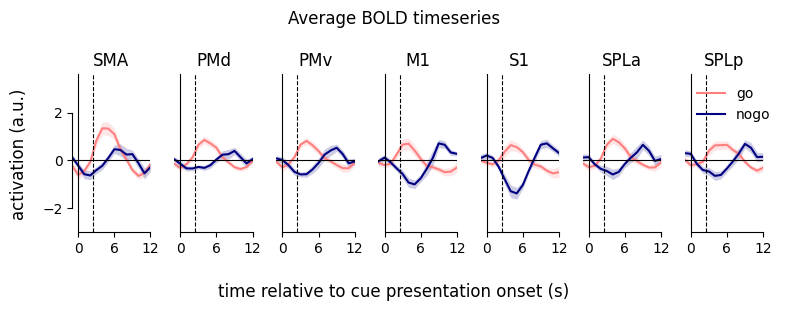

In [16]:
from vis import plot_bold

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 3))

tAx = np.arange(-1, 13)

for r, roi in enumerate(rois):
    ax = axs[r]
    go = np.load(os.path.join(gl.baseDir, experiment, f'glm{glm}',f'hrf_go.{H}.{roi}.npy'))
    nogo = np.load(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'hrf_nogo.{H}.{roi}.npy'))
    y_adj_go = go.mean(axis=0)
    y_adj_go_err = go.std(axis=0) / np.sqrt(go.shape[0])
    y_adj_nogo = nogo.mean(axis=0)
    y_adj_nogo_err = nogo.std(axis=0) / np.sqrt(nogo.shape[0])

    ax.plot(tAx, y_adj_go, color='#FF7F7F', label='go', ls='-')
    ax.plot(tAx, y_adj_nogo, color='#000080', label='nogo', ls='-')
    ax.fill_between(tAx, y_adj_go - y_adj_go_err, y_adj_go + y_adj_go_err,
                    color='#FF7F7F', alpha=.2, lw=0)
    ax.fill_between(tAx, y_adj_nogo - y_adj_nogo_err, y_adj_nogo + y_adj_nogo_err,
                    color='#000080', alpha=.2, lw=0)

    ax.axvline(0, color='k', ls='-', lw=.8)
    ax.axvline(2.5, color='k', ls='--', lw=.8)
    ax.axhline(0, color='k', ls='-', lw=.8)

    ax.spines[['left', 'right', 'top']].set_visible(False)
    ax.spines['bottom'].set_bounds(0, 12)
    ax.set_xticks([0, 6, 12])
    if r == 0:
        ax.spines['left'].set_visible(True)
        ax.spines['left'].set_bounds(-2, 2)
    else:
        ax.tick_params('y', width=0)

    ax.set_xlim((-1, 12))
    ax.set_ylim((-3, 3.6))

    ax.set_title(rois[r])

ax.legend(frameon=False) #, bbox_to_anchor=(1, -.1), loc='upper right', )

fig.supylabel('activation (a.u.)')
fig.supxlabel('time relative to cue presentation onset (s)')
fig.suptitle(f'Average BOLD timeseries')
fig.tight_layout()

plt.show()

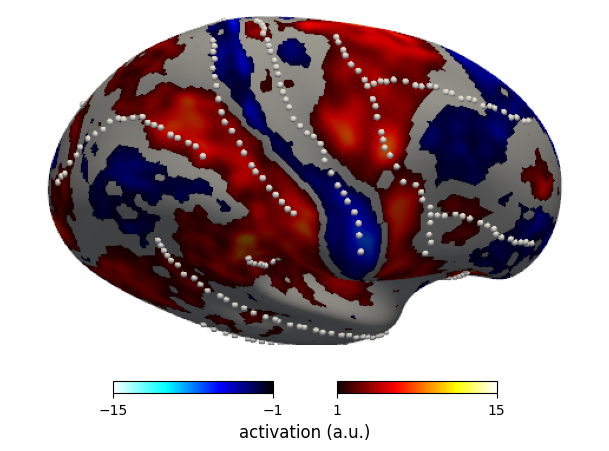

In [17]:
from vis import plot_surf

cold_colors = [(0, 0, 0), (0, 0, 1), (0, 1, 1), (1, 1, 1)]  # RGB tuples
cold = LinearSegmentedColormap.from_list('cold_custom', cold_colors, N=128)
hot = plt.cm.hot(np.linspace(0, 1, 128))
cold_vals = cold(np.linspace(1, 0, 128))  # reversed
combined = np.vstack((cold_vals, hot))
cmap = LinearSegmentedColormap.from_list('coldhot', combined)

dtype = 'con'
thresh = 1
vmin, vmax = -15, 15

cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.wbDir, f'glm{glm}.{dtype}.plan-exec.smooth.dscalar.nii'))
fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, cifti, H, cmap=cmap, col=0, thresh=thresh, vmin=vmin, vmax=vmax)

cold_half = LinearSegmentedColormap.from_list("cold_half", combined[:128])
hot_half = LinearSegmentedColormap.from_list("hot_half", combined[128:])

neg_norm = Normalize(vmin=vmin, vmax=-thresh)
sm_neg = ScalarMappable(norm=neg_norm, cmap=cold_half)
cax_neg = fig.add_axes([0.2, 0.1, 0.25, 0.025])
cbar_neg = fig.colorbar(sm_neg, ax=ax, cax=cax_neg, fraction=0.03, pad=0.02, orientation='horizontal')
cbar_neg.set_ticks([vmin, -thresh])
fig.supxlabel('activation (a.u.)', y=.001)

pos_norm = Normalize(vmin=thresh, vmax=vmax)
sm_pos = ScalarMappable(norm=pos_norm, cmap=hot_half)
cax_pos = fig.add_axes([0.55, 0.1, 0.25, 0.025])
cbar_pos = fig.colorbar(sm_pos, ax=ax, cax=cax_pos, fraction=0.03, pad=0.08, orientation='horizontal')
cbar_pos.set_ticks([thresh, vmax])
plt.subplots_adjust(left=0, right=1, bottom=.2, top=.9)

plt.show()

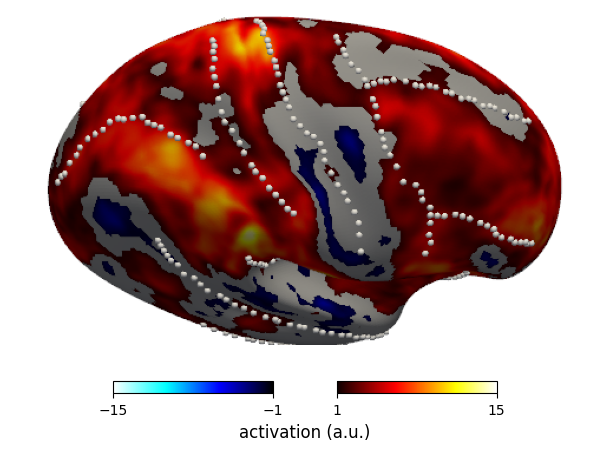

In [18]:
fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, cifti, H, cmap=cmap, col=1, thresh=thresh, vmin=vmin, vmax=vmax)

cax_neg = fig.add_axes([0.2, 0.1, 0.25, 0.025])
cbar_neg = fig.colorbar(sm_neg, ax=ax, cax=cax_neg, fraction=0.03, pad=0.02, orientation='horizontal')
cbar_neg.set_ticks([vmin, -thresh])
fig.supxlabel('activation (a.u.)', y=.001)

cax_pos = fig.add_axes([0.55, 0.1, 0.25, 0.025])
cbar_pos = fig.colorbar(sm_pos, ax=ax, cax=cax_pos, fraction=0.03, pad=0.08, orientation='horizontal')
cbar_pos.set_ticks([thresh, vmax])
plt.subplots_adjust(left=0, right=1, bottom=.2, top=.9)

plt.show()

ROI: SMA
planning vs. execution: tval=-0.5221651534046483, pval=0.610338076306107
planning vs. 0: tval=3.040967689071341, pval=0.009463014301061229
execution vs. 0: tval=2.9764484820303845, pval=0.01071320000929254
ROI: PMd
planning vs. execution: tval=-0.45322273493118564, pval=0.6578607059964232
planning vs. 0: tval=2.850637334813147, pval=0.013640286876735555
execution vs. 0: tval=2.130359885596176, pval=0.052814839984209695
ROI: PMv
planning vs. execution: tval=-0.644546564830475, pval=0.5304306926645295
planning vs. 0: tval=2.7275947868131825, pval=0.017260869710321567
execution vs. 0: tval=1.493791539343153, pval=0.15910072446468745
ROI: M1
planning vs. execution: tval=0.32836057906305316, pval=0.7478679953580869
planning vs. 0: tval=0.5314556759868615, pval=0.6040659025994195
execution vs. 0: tval=1.1865301889390254, pval=0.25664497165167943
ROI: S1
planning vs. execution: tval=2.10501075707738, pval=0.05530715798865337
planning vs. 0: tval=-0.7793795119985507, pval=0.4497124391

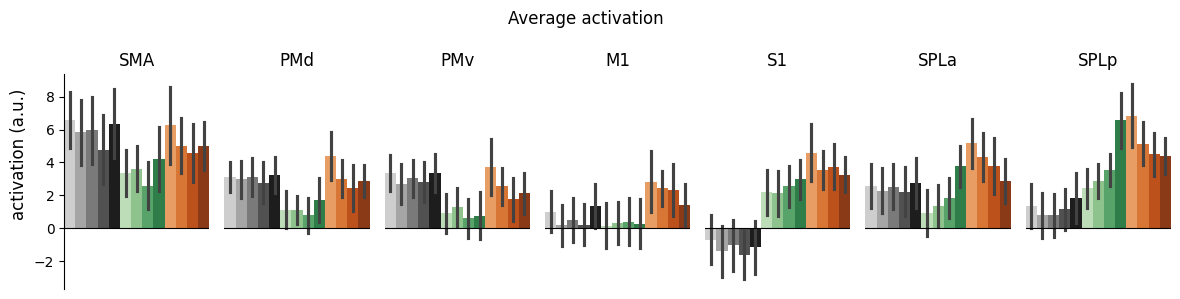

In [19]:
from vis import plot_avg_activation

df_con = pd.read_csv(os.path.join(gl.baseDir, experiment, f'glm{glm}','ROI.con.avg.tsv'), sep='\t')
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(12, 3))
fig, axs = plot_avg_activation(fig, axs, df_con, H, rois)
df_con_stat = df_con.groupby(['sn', 'roi', 'Hem', 'epoch']).mean(numeric_only=True).reset_index()
for roi in rois:
    plan = df_con_stat[(df_con_stat['roi'] == roi) & (df_con_stat['Hem'] == H) & (df_con_stat['epoch'] == 'plan')]['con']
    exec = df_con_stat[(df_con_stat['roi'] == roi) & (df_con_stat['Hem'] == H) & (df_con_stat['epoch'] == 'exec')]['con']
    print(f'ROI: {roi}')
    tval, pval = ttest_rel(exec, plan)
    print(f'planning vs. execution: tval={tval}, pval={pval}')
    tval, pval = ttest_1samp(plan, 0, alternative='two-sided')
    print(f'planning vs. 0: tval={tval}, pval={pval}')
    tval, pval = ttest_1samp(exec, 0)
    print(f'execution vs. 0: tval={tval}, pval={pval}')
fig.supylabel('activation (a.u.)')
fig.suptitle(f'Average activation')
fig.tight_layout()